# Eksperimen Baseline

In [16]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")

if os.path.basename(os.getcwd()) == "notebook":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 40, "display.width", 200)

RANDOM_STATE = 42
os.makedirs("results", exist_ok=True)

## 1. Formulasi tugas

### 1.1 Definisi target

Misalkan $P_t$ adalah kurs JISDOR pada hari perdagangan $t$. Target utama adalah **selisih harian**:

$$y_t = \Delta P_t = P_t - P_{t-1}$$

Dua formulasi dievaluasi berdampingan dari prediksi yang sama:

| Formulasi | Target | Metrik |
|---|---|---|
| **Regresi** | $\Delta P_t$ | RMSE, MAE |
| **Klasifikasi arah** | $\mathbb{1}[\Delta P_t > 0]$ | Directional Accuracy, F1 |

### 1.2 Mengapa selisih, bukan level kurs

Alasannya rentang target tidak bertumpang tindih antarsplit, dapat dilihat pada Notebook EDA. 

In [17]:
train = pd.read_csv("data/splits/train.csv", parse_dates=["tanggal"])
val   = pd.read_csv("data/splits/val.csv",   parse_dates=["tanggal"])
test  = pd.read_csv("data/splits/test.csv",  parse_dates=["tanggal"])

y_train, y_val, y_test = (d["kurs_diff"].to_numpy() for d in (train, val, test))

# news_count dikeluarkan: Notebook 1 menunjukkan ia proksi waktu (2/hari di
# train vs 23/hari di test), bukan proksi intensitas berita.
EXCLUDE = ["tanggal", "kurs", "kurs_diff", "news_count"]
fitur = [c for c in train.columns if c not in EXCLUDE]

print(f"Train {len(train)} | Val {len(val)} | Test {len(test)}")
print(f"Jumlah fitur: {len(fitur)}")
print(f"  autoregresif : {[c for c in fitur if 'kurs' in c]}")
print(f"  lexicon      : {len([c for c in fitur if 'vader' in c or 'lm_' in c])}")
print(f"  TF-IDF/SVD   : {len([c for c in fitur if 'svd_' in c])}")

Train 840 | Val 180 | Test 180
Jumlah fitur: 156
  autoregresif : ['kurs_diff_lag1']
  lexicon      : 80
  TF-IDF/SVD   : 75


In [18]:
def directional_accuracy(y_true, y_pred):
    """Persentase arah yang tertebak benar, mengabaikan hari tanpa perubahan."""
    t, p = np.sign(np.asarray(y_true)), np.sign(np.asarray(y_pred))
    mask = t != 0
    return float(np.mean(t[mask] == p[mask]) * 100)

def evaluasi(nama, split, y_true, y_pred):
    """Menghitung seluruh metrik untuk satu model pada satu split."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    rmse_naif = float(np.sqrt(np.mean(y_true ** 2)))   # baseline: prediksi nol
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    # Baseline naif memprediksi nol untuk semua hari, jadi ia tidak membuat
    # prediksi arah sama sekali. Metrik arahnya dikosongkan agar tidak
    # disalahbaca sebagai "0% benar".
    if np.all(y_pred == 0):
        da = f1_naik = f1_macro = np.nan
    else:
        mask = np.sign(y_true) != 0
        benar = (y_true[mask] > 0).astype(int)
        tebak = (y_pred[mask] > 0).astype(int)
        da = directional_accuracy(y_true, y_pred)
        f1_naik = f1_score(benar, tebak, pos_label=1, zero_division=0)
        f1_macro = f1_score(benar, tebak, average="macro", zero_division=0)

    return {
        "model": nama, "split": split, "n": len(y_true),
        "RMSE": round(rmse, 2),
        "MAE": round(float(mean_absolute_error(y_true, y_pred)), 2),
        "DA (%)": round(da, 1) if da == da else np.nan,
        "F1 naik": round(f1_naik, 3) if f1_naik == f1_naik else np.nan,
        "F1 macro": round(f1_macro, 3) if f1_macro == f1_macro else np.nan,
        # Skill > 0 berarti mengalahkan random walk.
        "skill (%)": round((1 - rmse / rmse_naif) * 100, 2),
    }

## 2. Model Baseline

In [19]:
hasil = []

# --- Baseline 1: Naive Random Walk ---
for split, y in [("val", y_val), ("test", y_test)]:
    hasil.append(evaluasi("Naive RW", split, y, np.zeros(len(y))))

# --- Baseline 2: Majority Class (arah mayoritas periode TRAIN) ---
arah_mayoritas = 1.0 if (y_train > 0).mean() > 0.5 else -1.0
print(f"Arah mayoritas periode train: {'NAIK' if arah_mayoritas > 0 else 'TURUN'} "
      f"({(y_train > 0).mean():.1%} hari naik)")
for split, y in [("val", y_val), ("test", y_test)]:
    hasil.append(evaluasi("Majority Class", split, y, np.full(len(y), arah_mayoritas)))

# --- Baseline 3: Persistence (arah kemarin) ---
for split, y, d in [("val", y_val, val), ("test", y_test, test)]:
    hasil.append(evaluasi("Persistence", split, y, d["kurs_diff_lag1"].to_numpy()))

pd.DataFrame(hasil)

Arah mayoritas periode train: NAIK (55.6% hari naik)


,model,split,n,RMSE,MAE,DA (%),F1 naik,F1 macro,skill (%)
0,Naive RW,val,180,55.58,40.44,NaN,NaN,NaN,0.00
1,Naive RW,test,180,51.00,38.43,NaN,NaN,NaN,0.00
2,Majority Class,val,180,55.55,40.40,52.8,0.691,0.346,0.05
3,Majority Class,test,180,50.90,38.28,59.1,0.743,0.371,0.20
4,Persistence,val,180,75.76,56.77,50.6,0.540,0.509,-36.30
5,Persistence,test,180,69.94,54.08,54.0,0.612,0.532,-37.13


## 3. ARIMAX

In [20]:
def rolling_arima(y_hist, y_future, order, X_hist=None, X_future=None):
    model = ARIMA(endog=y_hist, exog=X_hist, order=order,
                  enforce_stationarity=False, enforce_invertibility=False).fit()
    preds = []
    for t in range(len(y_future)):
        exog_t = X_future[t:t + 1] if X_future is not None else None
        preds.append(float(np.asarray(model.forecast(steps=1, exog=exog_t)).ravel()[0]))
        model = model.append(y_future[t:t + 1], exog=exog_t, refit=False)
    return np.asarray(preds)


baris = []
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        try:
            res = ARIMA(endog=y_train, order=(p, 0, q)).fit()
            baris.append({"order": (p, 0, q), "AIC": round(res.aic, 2), "BIC": round(res.bic, 2)})
        except Exception:
            continue

tabel_aic = pd.DataFrame(baris).sort_values("AIC").reset_index(drop=True)
order_arima = tabel_aic.loc[0, "order"]
tabel_aic.head(5)

pred_arima_val = rolling_arima(y_train, y_val, order_arima)
hasil.append(evaluasi(f"ARIMA{order_arima}", "val", y_val, pred_arima_val))

y_trainval = np.concatenate([y_train, y_val])
pred_arima_test = rolling_arima(y_trainval, y_test, order_arima)
hasil.append(evaluasi(f"ARIMA{order_arima}", "test", y_test, pred_arima_test))

pd.DataFrame(hasil[-2:])

EXOG = ["title_vader_compound_mean", "title_lm_polarity_mean",
        "text_vader_compound_mean", "text_lm_polarity_mean"]
EXOG = [c for c in EXOG if c in train.columns]
print("Variabel eksogen:", EXOG)

# --- Validasi ---
scaler_val = StandardScaler().fit(train[EXOG].values)
Xtr = scaler_val.transform(train[EXOG].values)
Xva = scaler_val.transform(val[EXOG].values)

baris = []
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        try:
            res = ARIMA(endog=y_train, exog=Xtr, order=(p, 0, q)).fit()
            baris.append({"order": (p, 0, q), "AIC": round(res.aic, 2)})
        except Exception:
            continue
tabel_aic_x = pd.DataFrame(baris).sort_values("AIC").reset_index(drop=True)
order_arimax = tabel_aic_x.loc[0, "order"]
print(f"Order ARIMAX terpilih (AIC, train saja): ARIMAX{order_arimax}")

pred_arimax_val = rolling_arima(y_train, y_val, order_arimax, X_hist=Xtr, X_future=Xva)
hasil.append(evaluasi(f"ARIMAX{order_arimax} + NLP", "val", y_val, pred_arimax_val))

# --- Test: scaler di-fit ulang pada train+val ---
trainval = pd.concat([train, val], ignore_index=True)
scaler_test = StandardScaler().fit(trainval[EXOG].values)
Xtv = scaler_test.transform(trainval[EXOG].values)
Xte = scaler_test.transform(test[EXOG].values)

pred_arimax_test = rolling_arima(y_trainval, y_test, order_arimax, X_hist=Xtv, X_future=Xte)
hasil.append(evaluasi(f"ARIMAX{order_arimax} + NLP", "test", y_test, pred_arimax_test))

pd.DataFrame(hasil[-2:])

Variabel eksogen: ['title_vader_compound_mean', 'title_lm_polarity_mean', 'text_vader_compound_mean', 'text_lm_polarity_mean']
Order ARIMAX terpilih (AIC, train saja): ARIMAX(2, 0, 2)


,model,split,n,RMSE,MAE,DA (%),F1 naik,F1 macro,skill (%)
0,"ARIMAX(2, 0, 2) + NLP",val,180,55.55,41.57,50.6,0.546,0.502,0.06
1,"ARIMAX(2, 0, 2) + NLP",test,180,51.11,38.43,53.4,0.617,0.511,-0.22


## 4. XGBoost

In [21]:
kelompok = {
    "harga":       [c for c in fitur if "kurs" in c],
    "NLP":         [c for c in fitur if "kurs" not in c],
    "harga + NLP": fitur,
}
for k, v in kelompok.items():
    print(f"  {k:<12} {len(v):>3} fitur")

GRID = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05],
    "max_depth": [2, 3, 5],
}

params_terpilih, importance_final, pred_xgb = {}, {}, {}

for nama, cols in kelompok.items():
    best = {"rmse": np.inf, "params": None}
    for params in ParameterGrid(GRID):
        m = xgb.XGBRegressor(**params, random_state=RANDOM_STATE,
                             objective="reg:squarederror", n_jobs=4)
        m.fit(train[cols], y_train, verbose=False)
        rmse = np.sqrt(mean_squared_error(y_val, m.predict(val[cols])))
        if rmse < best["rmse"]:
            best = {"rmse": rmse, "params": params}

    params_terpilih[nama] = best["params"]

    # Prediksi validasi: model dilatih pada train saja.
    m_val = xgb.XGBRegressor(**best["params"], random_state=RANDOM_STATE,
                             objective="reg:squarederror", n_jobs=4).fit(train[cols], y_train)
    # Prediksi test: model dilatih ulang pada train + val.
    m_test = xgb.XGBRegressor(**best["params"], random_state=RANDOM_STATE,
                              objective="reg:squarederror", n_jobs=4).fit(trainval[cols], y_trainval)

    pred_xgb[nama] = {"val": m_val.predict(val[cols]), "test": m_test.predict(test[cols])}
    hasil.append(evaluasi(f"XGB ({nama})", "val", y_val, pred_xgb[nama]["val"]))
    hasil.append(evaluasi(f"XGB ({nama})", "test", y_test, pred_xgb[nama]["test"]))

    importance_final[nama] = pd.DataFrame(
        {"fitur": cols, "gain": m_test.feature_importances_}
    ).sort_values("gain", ascending=False).reset_index(drop=True)

json.dump({k: v for k, v in params_terpilih.items()},
          open("results/best_xgb_params.json", "w"), indent=2)
pd.DataFrame(hasil[-6:])

  harga          1 fitur
  NLP          155 fitur
  harga + NLP  156 fitur


,model,split,n,RMSE,MAE,DA (%),F1 naik,F1 macro,skill (%)
0,XGB (harga),val,180,55.17,40.62,52.8,0.661,0.442,0.75
1,XGB (harga),test,180,50.42,38.13,57.4,0.713,0.444,1.13
2,XGB (NLP),val,180,55.58,40.54,52.8,0.691,0.346,0.01
3,XGB (NLP),test,180,50.99,38.28,58.5,0.711,0.487,0.02
4,XGB (harga + NLP),val,180,55.24,40.66,54.5,0.669,0.470,0.62
5,XGB (harga + NLP),test,180,51.42,38.79,47.2,0.551,0.455,-0.83


## 5. Hasil lengkap

In [22]:
tabel = pd.DataFrame(hasil)
tabel_test = tabel[tabel["split"] == "test"].reset_index(drop=True)
tabel_val  = tabel[tabel["split"] == "val"].reset_index(drop=True)

tabel.to_csv("results/hasil_eksperimen.csv", index=False)
tabel_test

,model,split,n,RMSE,MAE,DA (%),F1 naik,F1 macro,skill (%)
0,Naive RW,test,180,51.00,38.43,NaN,NaN,NaN,0.00
1,Majority Class,test,180,50.90,38.28,59.1,0.743,0.371,0.20
2,Persistence,test,180,69.94,54.08,54.0,0.612,0.532,-37.13
3,"ARIMA(2, 0, 2)",test,180,51.15,38.43,52.8,0.618,0.501,-0.29
4,"ARIMAX(2, 0, 2) + NLP",test,180,51.11,38.43,53.4,0.617,0.511,-0.22
5,XGB (harga),test,180,50.42,38.13,57.4,0.713,0.444,1.13
6,XGB (NLP),test,180,50.99,38.28,58.5,0.711,0.487,0.02
7,XGB (harga + NLP),test,180,51.42,38.79,47.2,0.551,0.455,-0.83


In [23]:
tabel_val

,model,split,n,RMSE,MAE,DA (%),F1 naik,F1 macro,skill (%)
0,Naive RW,val,180,55.58,40.44,NaN,NaN,NaN,0.00
1,Majority Class,val,180,55.55,40.40,52.8,0.691,0.346,0.05
2,Persistence,val,180,75.76,56.77,50.6,0.540,0.509,-36.30
3,"ARIMA(2, 0, 2)",val,180,55.57,41.47,52.2,0.585,0.511,0.02
4,"ARIMAX(2, 0, 2) + NLP",val,180,55.55,41.57,50.6,0.546,0.502,0.06
5,XGB (harga),val,180,55.17,40.62,52.8,0.661,0.442,0.75
6,XGB (NLP),val,180,55.58,40.54,52.8,0.691,0.346,0.01
7,XGB (harga + NLP),val,180,55.24,40.66,54.5,0.669,0.470,0.62


## 6. Fitur mana yang dipakai model?

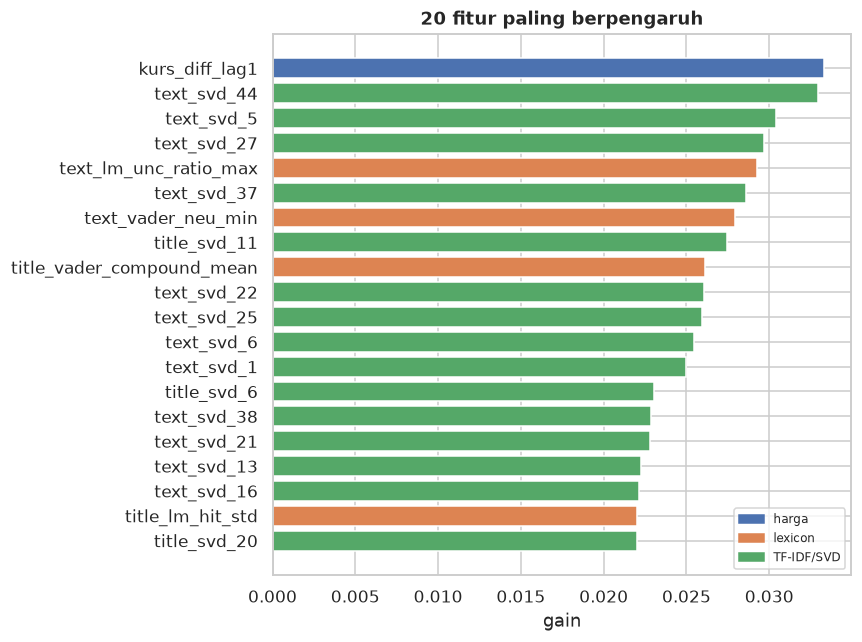

Total gain per kelompok (20 fitur teratas):
kelompok
TF-IDF/SVD    0.3866
lexicon       0.1053
harga         0.0333


In [24]:
imp = importance_final["harga + NLP"].head(20).copy()

def label(nama):
    if "kurs" in nama: return "harga"
    if "svd" in nama:  return "TF-IDF/SVD"
    return "lexicon"

imp["kelompok"] = imp["fitur"].map(label)
peta = {"harga": "#4C72B0", "lexicon": "#DD8452", "TF-IDF/SVD": "#55A868"}

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp["fitur"][::-1], imp["gain"][::-1], color=[peta[k] for k in imp["kelompok"][::-1]])
ax.set_title("20 fitur paling berpengaruh")
ax.set_xlabel("gain")
ax.legend([plt.Rectangle((# Test: fit pada train+val, rolling melewati test.
0, 0), 1, 1, color=c) for c in peta.values()], peta.keys(), fontsize=8)
plt.tight_layout(); plt.show()

print("Total gain per kelompok (20 fitur teratas):")
print(imp.groupby("kelompok")["gain"].sum().round(4).sort_values(ascending=False).to_string())

## 7. Visualisasi prediksi

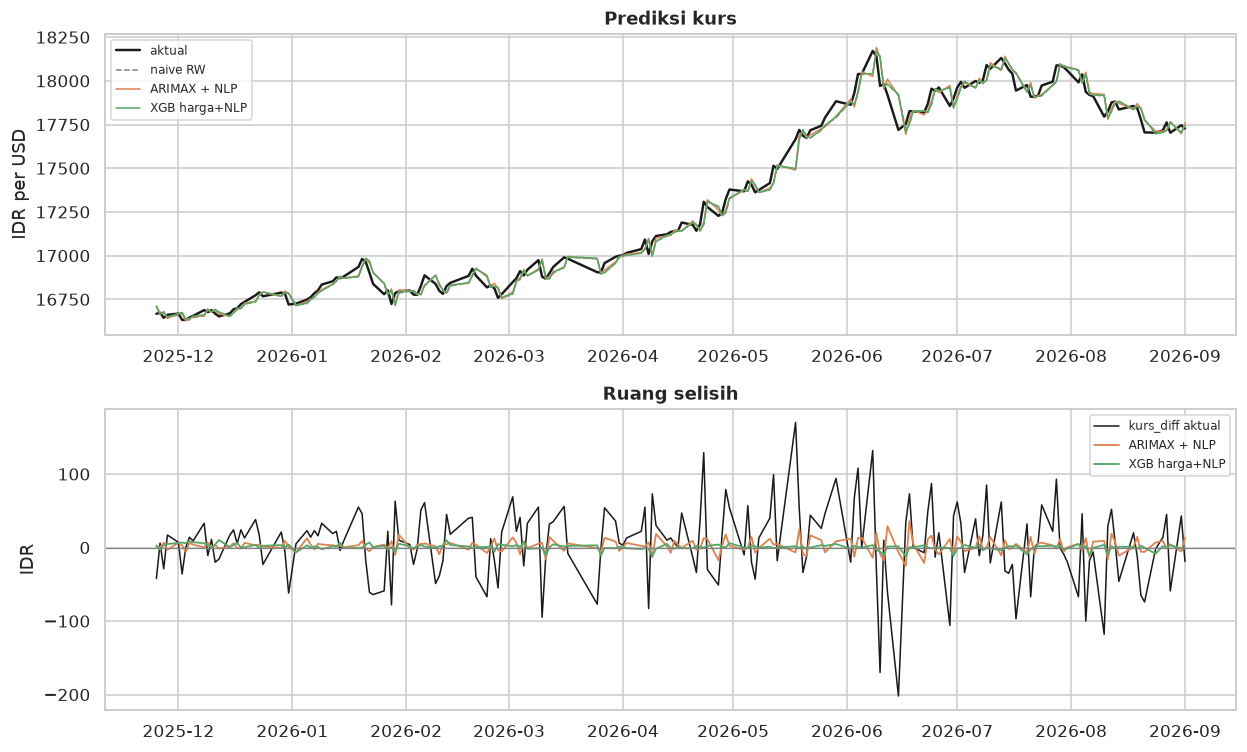

Std kurs_diff aktual      : 50.69
Std prediksi ARIMAX + NLP : 9.09
Std prediksi XGB          : 3.83


In [26]:
kurs_kemarin = test["kurs"].to_numpy() - y_test   # P_(t-1)

fig, axes = plt.subplots(2, 1, figsize=(11.5, 7))

axes[0].plot(test["tanggal"], test["kurs"], color="k", lw=1.6, label="aktual")
axes[0].plot(test["tanggal"], kurs_kemarin, color="gray", lw=1, ls="--", label="naive RW")
axes[0].plot(test["tanggal"], kurs_kemarin + pred_arimax_test,
             color="#DD8452", lw=1, label="ARIMAX + NLP")
axes[0].plot(test["tanggal"], kurs_kemarin + pred_xgb["harga + NLP"]["test"],
             color="#55A868", lw=1, label="XGB harga+NLP")
axes[0].set_title("Prediksi kurs")
axes[0].set_ylabel("IDR per USD"); axes[0].legend(fontsize=8)

axes[1].plot(test["tanggal"], y_test, color="k", lw=1, label="kurs_diff aktual")
axes[1].plot(test["tanggal"], pred_arimax_test, color="#DD8452", lw=1.2, label="ARIMAX + NLP")
axes[1].plot(test["tanggal"], pred_xgb["harga + NLP"]["test"],
             color="#55A868", lw=1.2, label="XGB harga+NLP")
axes[1].axhline(0, color="gray", lw=0.8)
axes[1].set_title("Ruang selisih")
axes[1].set_ylabel("IDR"); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"Std kurs_diff aktual      : {y_test.std():.2f}")
print(f"Std prediksi ARIMAX + NLP : {pred_arimax_test.std():.2f}")
print(f"Std prediksi XGB          : {pred_xgb['harga + NLP']['test'].std():.2f}")